# **ASID Project: EDA notebook**

Theophilus Owiti
Group 8 Project

**Introduction**

This notebook does EDA on the merged dataset and also an extra step is done for model selection.

## **Import Python imports**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score


#custom libraries
from utils.stats_module import rices_rule
from utils.plotting import plot_histograms
from utils.model_eval import evaluate_model, utils_confusion_matrix, track_model_performance

## **1. Data Processing**

In this section the following operations are performed:

- Importing the data
- Wrangling the datasets
- Data Preprocessing

### **1.1 Data Wrangling**

In this section we import our data and perform data wrangling and data transformations and clean the data.

In [2]:
#import datasets using pandas

df_1 = pd.read_csv('data/Crop_recommendation.csv')
df_2 = pd.read_csv('data/sensor_Crop_Dataset.csv')

In [3]:
#see top of the data sets
df_1.head(2)

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice


In [4]:
#see top of the data sets
df_2.head(2)

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Rainfall,Crop,Soil_Type,Variety
0,69.074766,53.954402,88.067625,17.261834,72.941652,4.631301,302.842639,Wheat,Clay,Soft Red
1,107.329352,70.102134,32.081067,21.846116,99.361954,4.761658,94.693847,Tomato,Clay,Beefsteak


In [5]:
df_2["Variety"].unique()

<StringArray>
[  'Soft Red',  'Beefsteak',   'Co 86032',    'Co 0238',      'Sweet',
 'Yukon Gold',   'Hard Red',      'Flint',    'Basmati',   'Co 99004',
       'Dent',       'Roma',     'Russet',    'Jasmine',     'Cherry',
    'Arborio',        'Red',      'Durum']
Length: 18, dtype: str

Filtering the datasets needed for a merge.

In [6]:
#filtering needed dataset
df_1 = df_1[['N','P','K','temperature','humidity','ph','label']]
df_1.head(2)

,N,P,K,temperature,humidity,ph,label
0,90,42,43,20.879744,82.002744,6.502985,rice
1,85,58,41,21.770462,80.319644,7.038096,rice


In [7]:
feature_cols = ['Nitrogen','Phosphorus','Potassium','Temperature','Humidity','pH_Value','Crop']

In [8]:
df_2 = df_2[feature_cols]
df_2.head(2)

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Crop
0,69.074766,53.954402,88.067625,17.261834,72.941652,4.631301,Wheat
1,107.329352,70.102134,32.081067,21.846116,99.361954,4.761658,Tomato


In [9]:
#renaming dataframe 1 columns(df_1)
df_1.columns = feature_cols

In [10]:
#one last look
df_1.tail(2)

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Crop
2198,117,32,34,26.272418,52.127394,6.758793,coffee
2199,104,18,30,23.603016,60.396475,6.779833,coffee


In [11]:
#get their datashapes
print(f"Data Frame 1 shape: {df_1.shape}")
print(f"Data Frame 2 shape: {df_2.shape}")

Data Frame 1 shape: (2200, 7)
Data Frame 2 shape: (20000, 7)


Concatinating the dataset

In [12]:
#concatination of df1 and df2
sensor_df = pd.concat([df_2, df_1], axis=0)
#sensor_df = df_2

sensor_df.head()


,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Crop
0,69.074766,53.954402,88.067625,17.261834,72.941652,4.631301,Wheat
1,107.329352,70.102134,32.081067,21.846116,99.361954,4.761658,Tomato
2,130.634624,67.204533,28.294252,33.246895,81.506836,6.566007,Sugarcane
3,15.169301,87.493181,14.336679,14.396289,59.274465,6.296297,Sugarcane
4,21.881965,89.269712,38.833885,16.773218,51.191584,8.268274,Maize


In [13]:
#make the categories small letters
sensor_df["Crop"] = sensor_df["Crop"].str.lower()

In [14]:
#dataset shape
print(f"Data Frame shape: {sensor_df.shape}")

Data Frame shape: (22200, 7)


**Count the number of classes for each crop category**

This section shows you how many examples are available in each category given the crop's given class.

In [15]:
x = sensor_df.groupby("Crop").count()
x

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value
Crop,,,,,,
apple,100,100,100,100,100,100
banana,100,100,100,100,100,100
blackgram,100,100,100,100,100,100
chickpea,100,100,100,100,100,100
coconut,100,100,100,100,100,100
coffee,100,100,100,100,100,100
cotton,100,100,100,100,100,100
grapes,100,100,100,100,100,100
jute,100,100,100,100,100,100


Take in equal groups of each crop

In [16]:

samples = []

for crop_type in sensor_df["Crop"].unique():
    # Select rows for this crop
    crop_rows = sensor_df[sensor_df["Crop"] == crop_type]
    
    # Shuffle rigorously
    crop_rows = crop_rows.sample(frac=1, random_state=None).reset_index(drop=True)
    
    # Take up to 100 rows
    sampled = crop_rows.head(100)
    
    samples.append(sampled)

# Concatenate all sampled subsets
balanced_df = pd.concat(samples, axis=0).reset_index(drop=True)

# 🔀 Shuffle the entire balanced dataset
balanced_df = balanced_df.sample(frac=1, random_state=None).reset_index(drop=True)

# Verify distribution
print(balanced_df["Crop"].value_counts())
balanced_df.head(10)


Crop
orange         100
pomegranate    100
apple          100
banana         100
watermelon     100
coconut        100
chickpea       100
sugarcane      100
mango          100
mothbeans      100
grapes         100
potato         100
rice           100
cotton         100
blackgram      100
kidneybeans    100
jute           100
lentil         100
papaya         100
coffee         100
wheat          100
tomato         100
muskmelon      100
mungbean       100
maize          100
pigeonpeas     100
Name: count, dtype: int64


,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Crop
0,8.0,16.0,6.0,12.228162,90.264574,7.106650,orange
1,23.0,5.0,44.0,21.207254,94.263047,7.163005,pomegranate
2,20.0,129.0,201.0,23.410447,91.699133,5.587906,apple
3,99.0,73.0,53.0,26.290390,81.060038,5.871702,banana
4,97.0,22.0,50.0,26.260287,86.145859,6.769894,watermelon
5,17.0,11.0,32.0,28.740133,93.396765,5.620734,coconut
6,29.0,8.0,28.0,26.870376,91.725463,6.100429,coconut
7,6.0,144.0,198.0,21.114787,90.315287,5.559364,apple
8,109.0,10.0,53.0,26.819387,87.827460,6.551750,watermelon
9,95.0,75.0,50.0,28.081661,75.264298,5.623616,banana


In [17]:
sensor_df = balanced_df
sensor_df.head()

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Crop
0,8.0,16.0,6.0,12.228162,90.264574,7.106650,orange
1,23.0,5.0,44.0,21.207254,94.263047,7.163005,pomegranate
2,20.0,129.0,201.0,23.410447,91.699133,5.587906,apple
3,99.0,73.0,53.0,26.290390,81.060038,5.871702,banana
4,97.0,22.0,50.0,26.260287,86.145859,6.769894,watermelon


Drop Null/Nans

In [18]:
sensor_df.isna().sum()

Nitrogen       0
Phosphorus     0
Potassium      0
Temperature    0
Humidity       0
pH_Value       0
Crop           0
dtype: int64

In [19]:
sensor_df.shape

(2600, 7)

Check for the crops that are at least above 3000 (This section has been deprecated)

In [20]:
#sensor_df['Crop'].value_counts()[sensor_df['Crop'].value_counts() > 3000]

Create a new dataframe to take in the crops found above (Deprecated)

In [21]:
#sensor_df_filtered = sensor_df[sensor_df['Crop'].isin(["maize","wheat","rice","potato","tomato","sugarcane"])]
#sensor_df_filtered.count()

In [22]:
#sensor_df_filtered["Crop"].value_counts()

In [23]:
count_res = sensor_df.groupby("Crop").count()
count_res

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value
Crop,,,,,,
apple,100,100,100,100,100,100
banana,100,100,100,100,100,100
blackgram,100,100,100,100,100,100
chickpea,100,100,100,100,100,100
coconut,100,100,100,100,100,100
coffee,100,100,100,100,100,100
cotton,100,100,100,100,100,100
grapes,100,100,100,100,100,100
jute,100,100,100,100,100,100


Transform the dataset

In [24]:
#from sklearn.preprocessing import LabelEncoder
#le_variety = LabelEncoder()

#sensor_df_filtered['Soil_Type'] = le_variety.fit_transform(sensor_df_filtered['Soil_Type'])

Checking the mean and how many are below the mean

In [25]:
count_mean_data = sensor_df.groupby("Crop").aggregate("mean") #ignore variety
count_mean_data

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value
Crop,,,,,,
apple,20.800000,134.220000,199.890000,22.630942,92.333383,5.929663
banana,100.230000,82.010000,50.050000,27.376798,80.358123,5.983893
blackgram,40.020000,67.470000,19.240000,29.973340,65.118426,7.133952
chickpea,40.090000,67.790000,79.920000,18.872847,16.860439,7.336957
coconut,21.980000,16.930000,30.590000,27.409892,94.844272,5.976562
coffee,101.200000,28.740000,29.940000,25.540477,58.869846,6.790308
cotton,117.770000,46.240000,19.560000,23.988958,79.843474,6.912675
grapes,23.180000,132.530000,200.110000,23.849575,81.875228,6.025937
jute,78.400000,46.860000,39.990000,24.958376,79.639864,6.732778


**Getting outliers using Z-Score**

In [26]:
import numpy as np
import pandas as pd

# List of numeric columns to check
cols = list(sensor_df.columns)
cols = cols[0:len(cols)-1]

results = {}

for col in cols:
    #Z-score method
    z_scores = (sensor_df[col] - sensor_df[col].mean()) / sensor_df[col].std()
    z_outliers = (np.abs(z_scores) > 3).sum()
    
    #IQR method
    Q1 = sensor_df[col].quantile(0.25)
    Q3 = sensor_df[col].quantile(0.75)
    IQR = Q3 - Q1
    iqr_outliers = ((sensor_df[col] < Q1 - 1.5*IQR) | 
                    (sensor_df[col] > Q3 + 1.5*IQR)).sum()
    
    # Store results
    results[col] = {"Z-score_outliers": z_outliers, "IQR_outliers": iqr_outliers}

# Display nicely
outlier_df = pd.DataFrame(results).T
print(outlier_df)


             Z-score_outliers  IQR_outliers
Nitrogen                    0             0
Phosphorus                  0           108
Potassium                 200           200
Temperature                 0           172
Humidity                    0             0
pH_Value                   20            38


**Check for Correlation**

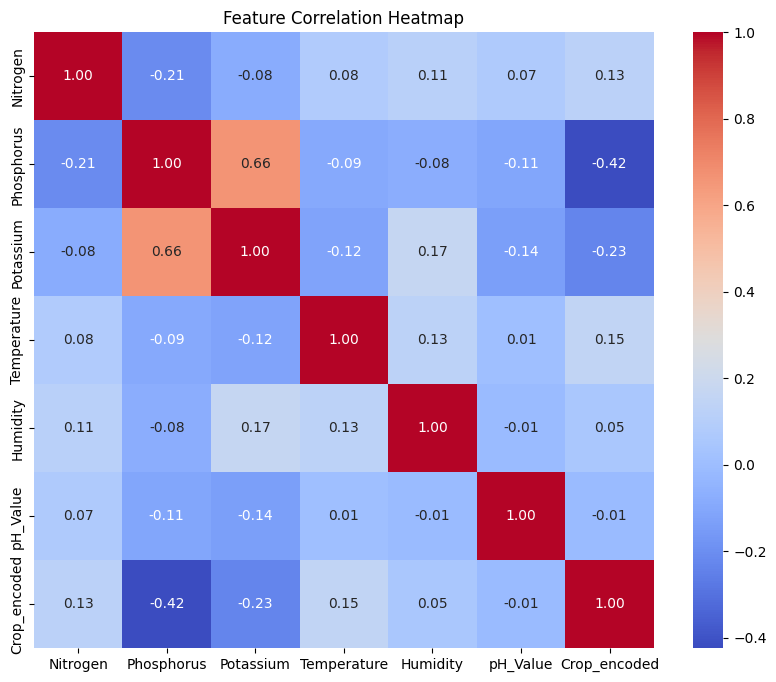

In [27]:
# Encode the Crop label to numbers to check correlation
df_corr = sensor_df.copy()
df_corr['Crop_encoded'] = df_corr['Crop'].astype('category').cat.codes

# Plot the heatmap
# Use numeric_only=True to automatically ignore the string columns
plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

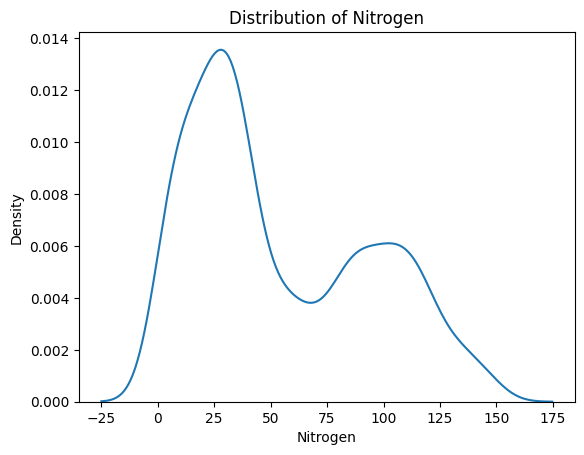

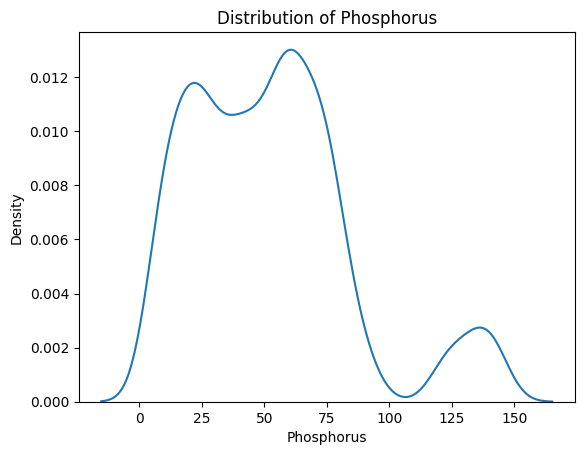

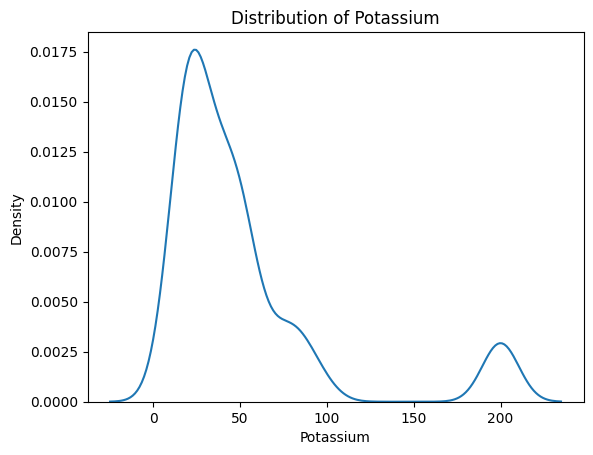

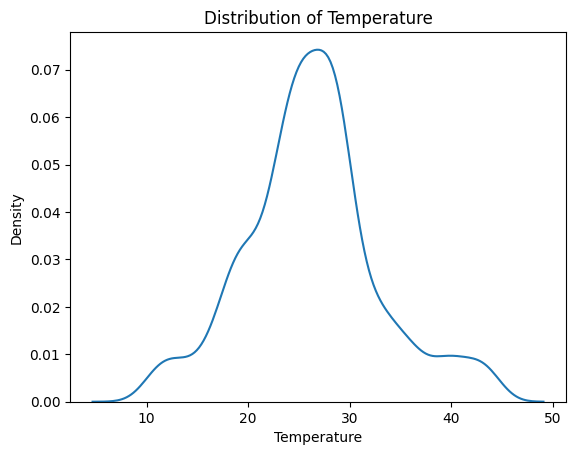

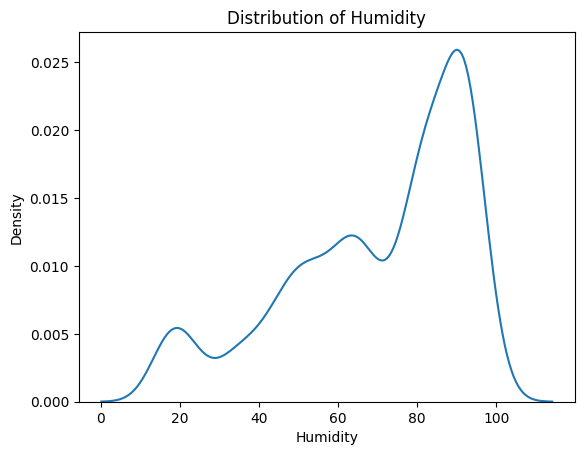

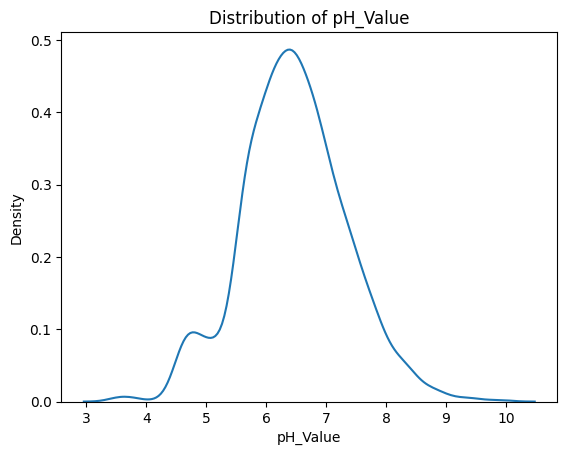

In [28]:
# Check means of features by the source dataset (if you have an identifier)
# If you don't have a 'source' column, you can check the histograms for 'double peaks'
for col in feature_cols[:-1]: # exclude 'Crop'
    sns.kdeplot(sensor_df[col])
    plt.title(f"Distribution of {col}")
    plt.show()

**Multicolinearity**

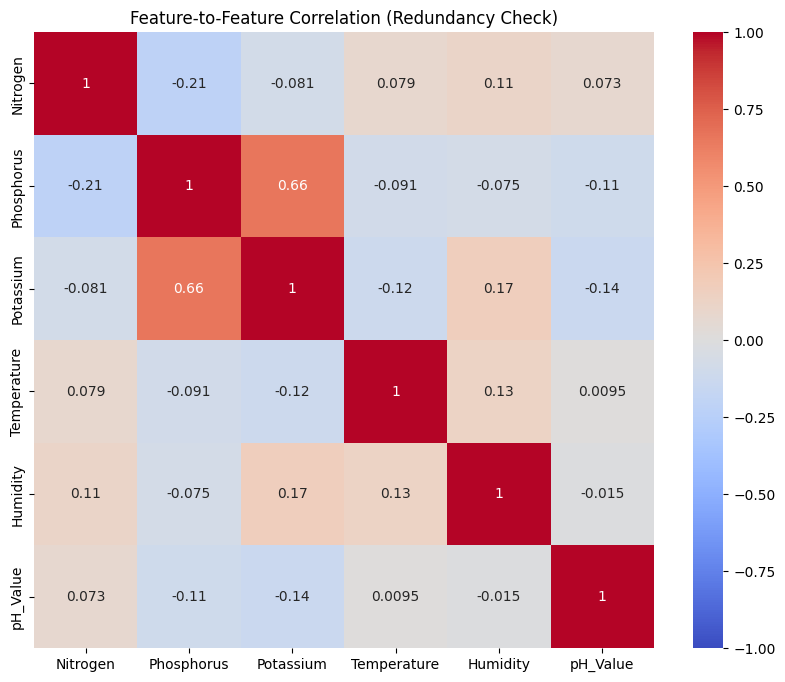

In [29]:
# Drop the target and check correlations among predictors
features_only = sensor_df.drop(columns=['Crop'])
correlation_matrix = features_only.corr()

# Visualize only the feature relationships (excluding Crop)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Feature-to-Feature Correlation (Redundancy Check)")
plt.show()

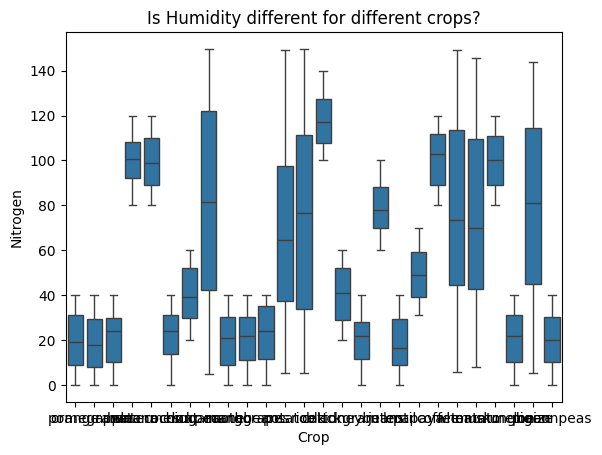

In [30]:
# Check the distributions of one feature across all 6 classes
# This will show you if, for example, 'Rice' has a different 'Humidity' than 'Tomato'
sns.boxplot(data=sensor_df, x='Crop', y='Nitrogen')
plt.title("Is Humidity different for different crops?")
plt.show()

The above indicates this is a data problem where all boxes/distributions are at the same level. The sensor does not change across different crops. Hence data merge becomes the primary issue.

## **1.2 Data Processing**

In this section we focus on preparing the data for analysis and modeling, improving its quality and usability.

**1.2.0 Changing the labels in target**

In [31]:
crop_categories = sensor_df["Crop"].str.lower().unique().tolist()
crop_categories_map = {}

for i in range(len(crop_categories)):
    crop_categories_map[crop_categories[i]] = i

print(crop_categories_map)

{'orange': 0, 'pomegranate': 1, 'apple': 2, 'banana': 3, 'watermelon': 4, 'coconut': 5, 'chickpea': 6, 'sugarcane': 7, 'mango': 8, 'mothbeans': 9, 'grapes': 10, 'potato': 11, 'rice': 12, 'cotton': 13, 'blackgram': 14, 'kidneybeans': 15, 'jute': 16, 'lentil': 17, 'papaya': 18, 'coffee': 19, 'wheat': 20, 'tomato': 21, 'muskmelon': 22, 'mungbean': 23, 'maize': 24, 'pigeonpeas': 25}


In [32]:
crop_categories

['orange',
 'pomegranate',
 'apple',
 'banana',
 'watermelon',
 'coconut',
 'chickpea',
 'sugarcane',
 'mango',
 'mothbeans',
 'grapes',
 'potato',
 'rice',
 'cotton',
 'blackgram',
 'kidneybeans',
 'jute',
 'lentil',
 'papaya',
 'coffee',
 'wheat',
 'tomato',
 'muskmelon',
 'mungbean',
 'maize',
 'pigeonpeas']

In [33]:
#using custom map create above
sensor_df["Crop"] = sensor_df["Crop"].map(crop_categories_map)

In [34]:
#check
sensor_df.tail(3)

,Nitrogen,Phosphorus,Potassium,Temperature,Humidity,pH_Value,Crop
2597,115.854449,30.157388,61.965363,33.856030,47.406814,6.258528,21
2598,29.000000,140.000000,195.000000,23.640830,90.952579,5.560521,2
2599,30.000000,41.000000,15.000000,24.832066,44.170850,5.885097,9


**1.2.1 Checking for missing values and handling them**

In [35]:
#get missing values in every column
sensor_df.isna().sum()

Nitrogen       0
Phosphorus     0
Potassium      0
Temperature    0
Humidity       0
pH_Value       0
Crop           0
dtype: int64

**1.2.2 Checking for data distributions per column using histogram**

This is important to see the skewness of our dataset.

Since we expect some of our data to be skewed we the formula below to choose bin size, Rice's Rule:

let $n$ be number of observations

$$bins = \sqrt[3]{n} \times 2$$

In [36]:
feature_cols = list(sensor_df.columns)
feature_cols

['Nitrogen',
 'Phosphorus',
 'Potassium',
 'Temperature',
 'Humidity',
 'pH_Value',
 'Crop']

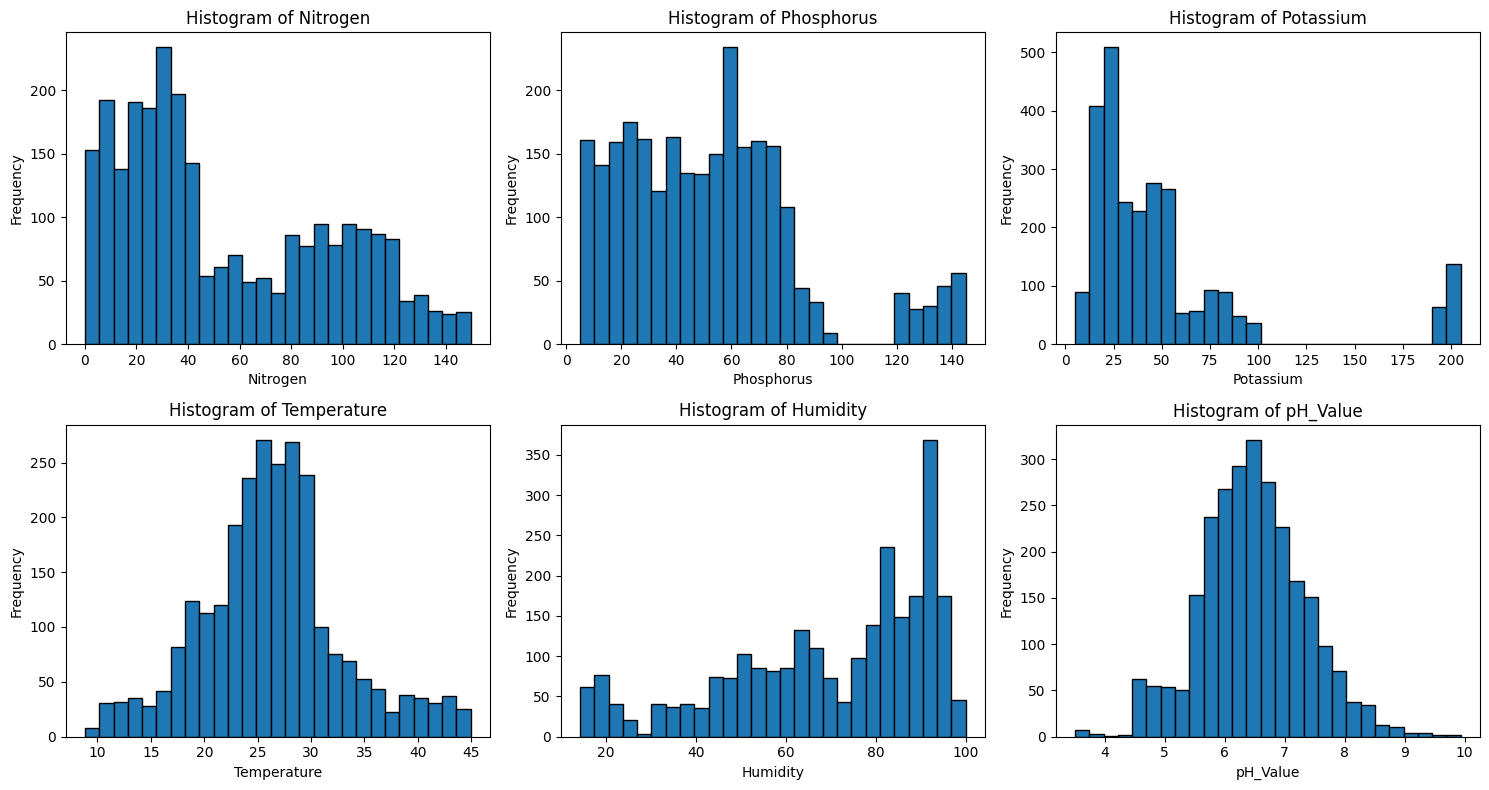

In [37]:
x_features = [x for x in feature_cols if x != "Crop"]
plot_histograms(features=x_features, df=sensor_df)

# Over all distribution

C:\Users\linco\AppData\Local\Temp\ipykernel_48688\125142205.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sensor_df[feat], color='greenyellow')
C:\Users\linco\AppData\Local\Temp\ipykernel_48688\125142205.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(sensor_df[feat], color='greenyello

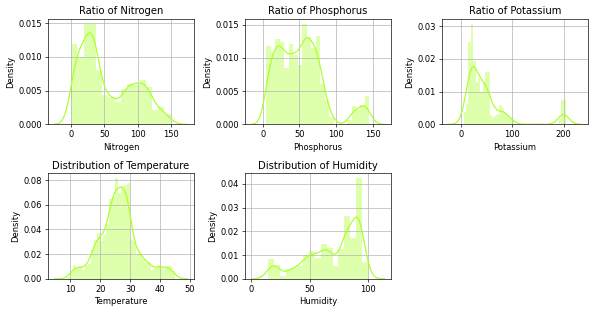

In [38]:
plt.rcParams['figure.figsize'] = (10, 10)
plt.rcParams['figure.dpi'] = 60



for i, feat in enumerate(feature_cols[0:len(feature_cols)-2]):
    plt.subplot(4, 3, i + 1)
    sns.distplot(sensor_df[feat], color='greenyellow')
    if i < 3:
        plt.title(f'Ratio of {feat}', fontsize=12)
    else:
        plt.title(f'Distribution of {feat}', fontsize=12)
    plt.tight_layout()
    plt.grid()

**Feature vs. Feature distributions for different crops**

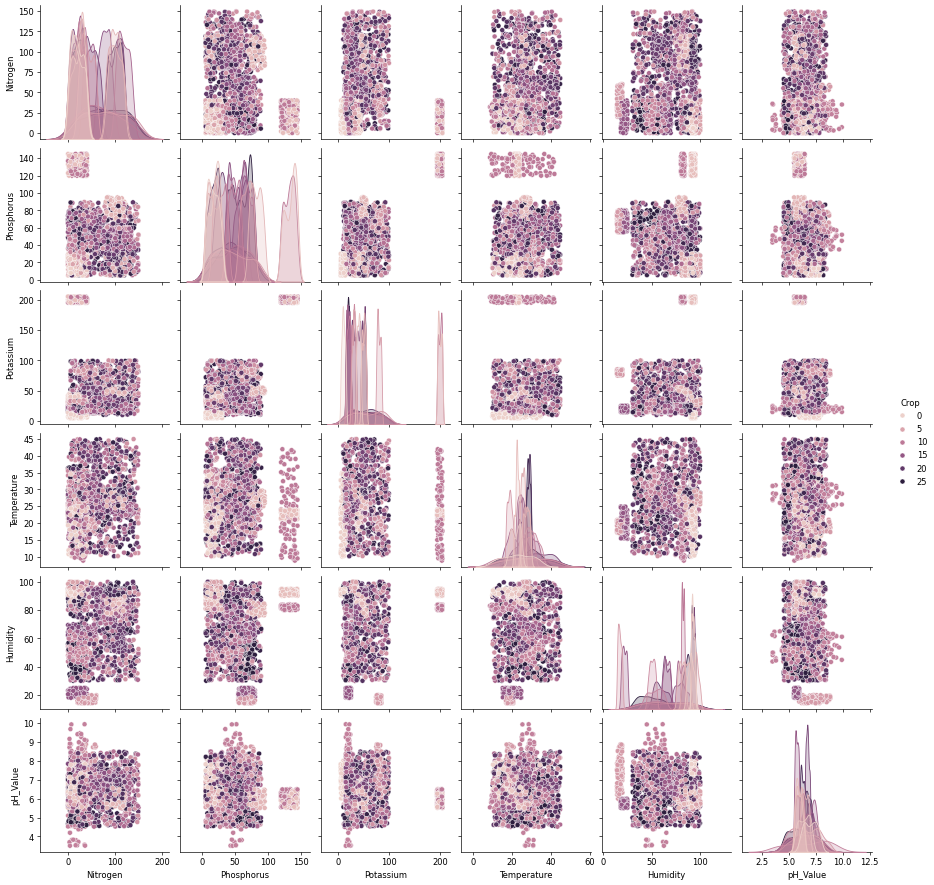

In [39]:
sns.pairplot(sensor_df, hue='Crop')

**1.2.3 Splitting features and performing transformations**

In [40]:
X = sensor_df.drop(columns=["Crop"])

y = sensor_df["Crop"]

print(f"Feature Shapes, X:{X.shape}, Y:{y.shape}")

feature_names = X.columns.tolist()
feature_names

#if using one dataframe default to this
#feature_names = ["Nitrogen","Phosphorus","Potassium","Temperature","Humidity","pH_Value","Rainfall"]
#X = X[feature_names]
#X.columns.tolist


Feature Shapes, X:(2600, 6), Y:(2600,)


['Nitrogen', 'Phosphorus', 'Potassium', 'Temperature', 'Humidity', 'pH_Value']

In [41]:
#splitting the data to train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


### Track Model Performance

In [42]:
import time

In [43]:
# Global list to store comparison data
model_comparison_data = []

**CatBoost Model**

In [44]:
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.001,
    depth=6,
    loss_function="MultiClass",
    verbose=False,
    random_state=42
)

start_train = time.time()
cat_model.fit(X_train, y_train)
end_train = time.time() - start_train

y_pred_cat = cat_model.predict(X_test)

cat_model_result = track_model_performance(cat_model, "CatBoost Classifier", X_test, y_test, y_pred_cat, end_train)

model_comparison_data.append(cat_model_result)



c:\Users\linco\Documents\projects\AISD project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [45]:
evaluate_model(y_test, y_pred_cat, "CatBoost")


CatBoost Results
Accuracy: 0.7519230769230769
Macro Precision: 0.6404258672103726
Macro Recall: 0.7519230769230769
Macro F1: 0.6793700104573708
Weighted Precision: 0.6404258672103725
Weighted Recall: 0.7519230769230769
Weighted F1: 0.679370010457371

Classification Report
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       0.83      1.00      0.91        20
           2       1.00      1.00      1.00        20
           3       0.69      1.00      0.82        20
           4       0.61      0.95      0.75        20
           5       0.91      1.00      0.95        20
           6       0.77      1.00      0.87        20
           7       0.25      0.05      0.08        20
           8       0.70      0.95      0.81        20
           9       0.77      0.85      0.81        20
          10       0.91      1.00      0.95        20
          11       0.00      0.00      0.00        20
          12       0.00

c:\Users\linco\Documents\projects\AISD project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\linco\Documents\projects\AISD project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\linco\Documents\projects\AISD project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

**XGBoot\ Lightgbm**

Log transfrom is applied

In [46]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')


In [47]:
skewed_features = ["Nitrogen","Phosphorus","Potassium","Humidity"]

X_train_log = X_train.copy()
X_test_log = X_test.copy()

for col in skewed_features:
    # This automatically handles the "best" transformation for each column
    X_train_log[skewed_features] = pt.fit_transform(X_train[skewed_features])
    X_test_log[skewed_features] = pt.transform(X_test[skewed_features])


In [48]:
#xgboost
xgb_model = XGBClassifier(
    objective="multi:softmax",
    num_class=y.nunique(),
    eval_metric="mlogloss",
    random_state=42
)





start_train = time.time()
xgb_model.fit(X_train, y_train)
end_train = time.time() - start_train

y_pred_xgb = xgb_model.predict(X_test)

xgboost_model_result = track_model_performance(xgb_model, "XGBoost Classifier", X_test, y_test, y_pred_xgb, end_train)

model_comparison_data.append(xgboost_model_result)


evaluate_model(y_test, y_pred_xgb, "XGBoost")



XGBoost Results
Accuracy: 0.801923076923077
Macro Precision: 0.7857008853719379
Macro Recall: 0.801923076923077
Macro F1: 0.7927342719089598
Weighted Precision: 0.785700885371938
Weighted Recall: 0.801923076923077
Weighted F1: 0.7927342719089598

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       0.95      1.00      0.98        20
           2       0.95      1.00      0.98        20
           3       0.95      1.00      0.98        20
           4       1.00      1.00      1.00        20
           5       0.95      0.90      0.92        20
           6       1.00      1.00      1.00        20
           7       0.14      0.10      0.12        20
           8       0.95      1.00      0.98        20
           9       0.90      0.95      0.93        20
          10       1.00      0.95      0.97        20
          11       0.19      0.15      0.17        20
          12       0.13    

In [49]:
#light GBM
lgbm_model = LGBMClassifier(
    objective="multiclass",
    random_state=42
)

start_time = time.time()

lgbm_model.fit(X_train_log, y_train)

end_time = time.time() - start_time

y_pred_lgbm = lgbm_model.predict(X_test_log)

lgbm_model_result = track_model_performance(lgbm_model, "Light GBM",X_test, y_test, y_pred_lgbm, end_time)

model_comparison_data.append(lgbm_model_result)


evaluate_model(y_test, y_pred_lgbm, "LightGBM")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000686 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1518
[LightGBM] [Info] Number of data points in the train set: 2080, number of used features: 6
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] [Info] Start training from score -3.258097
[LightGBM] 

**Random Forest**

In [50]:
#Random Forest
rf_model = RandomForestClassifier(
    n_estimators=330,
    random_state=128
)

str_time = time.time()
rf_model.fit(X_train_log, y_train)
training_end_time = time.time() - str_time

y_pred_rf = rf_model.predict(X_test_log)

rf_model_results = track_model_performance(rf_model, "Random Forest Model", X_test, y_test, y_pred_rf, training_end_time)

model_comparison_data.append(rf_model_results)


evaluate_model(y_test, y_pred_rf, "Random Forest")



Random Forest Results
Accuracy: 0.7903846153846154
Macro Precision: 0.7671863589626747
Macro Recall: 0.7903846153846155
Macro F1: 0.7777298789206822
Weighted Precision: 0.7671863589626747
Weighted Recall: 0.7903846153846154
Weighted F1: 0.7777298789206822

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       0.91      1.00      0.95        20
           2       1.00      1.00      1.00        20
           3       0.95      1.00      0.98        20
           4       1.00      1.00      1.00        20
           5       0.95      1.00      0.98        20
           6       1.00      1.00      1.00        20
           7       0.09      0.05      0.06        20
           8       0.95      0.90      0.92        20
           9       0.86      0.90      0.88        20
          10       1.00      1.00      1.00        20
          11       0.19      0.15      0.17        20
          12     

**Feature Importance**

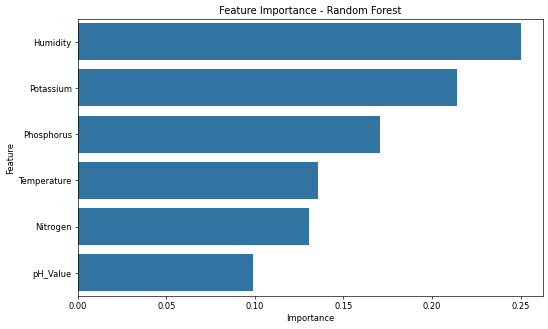

In [51]:
# Extract feature importance from your Random Forest model
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot the importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature')
plt.title("Feature Importance - Random Forest")
plt.show()

**Multinomial Logistic Regression**

In [52]:
preprocessor_lr = Pipeline(steps=[
    ("power", PowerTransformer(method="yeo-johnson")),
    ("scaler", StandardScaler())
])


In [53]:
lr_pipeline = Pipeline(
    steps=[ ("preprocessing", preprocessor_lr), 
           ("classifier", LogisticRegression(solver="lbfgs", max_iter=1000, n_jobs=-1 )) ])

s_time = time.time()
lr_pipeline.fit(X_train, y_train)
e_time = time.time() - s_time

y_pred_lr = lr_pipeline.predict(X_test)

lr_model_res = track_model_performance(lr_pipeline, "Multinomial Logistic Regression", X_test, y_test, y_pred_lr, e_time)

model_comparison_data.append(lr_model_res)

evaluate_model(y_test, y_pred_lr, "Logistic Regression")



Logistic Regression Results
Accuracy: 0.7326923076923076
Macro Precision: 0.6299376384601865
Macro Recall: 0.7326923076923078
Macro F1: 0.6718361683015638
Weighted Precision: 0.6299376384601865
Weighted Recall: 0.7326923076923076
Weighted F1: 0.6718361683015638

Classification Report
              precision    recall  f1-score   support

           0       1.00      0.95      0.97        20
           1       0.83      1.00      0.91        20
           2       1.00      1.00      1.00        20
           3       0.77      1.00      0.87        20
           4       0.70      0.95      0.81        20
           5       0.95      1.00      0.98        20
           6       0.87      1.00      0.93        20
           7       0.00      0.00      0.00        20
           8       0.73      0.95      0.83        20
           9       0.68      0.65      0.67        20
          10       1.00      1.00      1.00        20
          11       0.00      0.00      0.00        20
          1

c:\Users\linco\Documents\projects\AISD project\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


**Deep Learning  - MLP**

In [54]:
pt = PowerTransformer(method="yeo-johnson")
scaler = StandardScaler()

X_train_dl = scaler.fit_transform(pt.fit_transform(X_train))
X_test_dl = scaler.transform(pt.transform(X_test))


In [55]:
import tensorflow as tf
from keras import layers, models

model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X_train_dl.shape[1],)),
    layers.Dense(128, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(y.nunique(), activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


strart_train = time.time()
history = model.fit(
    X_train_dl, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=0
)
end_training = time.time() - strart_train



# Evaluate loss and accuracy
test_loss, test_acc = model.evaluate(X_test_dl, y_test, verbose=0)
print("Neural Network Accuracy:", test_acc)

# Get predicted probabilities
y_pred_probs = model.predict(X_test_dl)


# Convert probabilities to predicted class
import numpy as np
y_pred_nn = np.argmax(y_pred_probs, axis=1)


mlp_model_result = track_model_performance(model, "Neural Net (TensorFlow)",X_test_dl, y_test, y_pred_nn, end_training)

model_comparison_data.append(mlp_model_result)

# Evaluate using your metrics
evaluate_model(y_test, y_pred_nn, "TensorFlow Neural Network")


c:\Users\linco\Documents\projects\AISD project\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Neural Network Accuracy: 0.7730769515037537
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

TensorFlow Neural Network Results
Accuracy: 0.7730769230769231
Macro Precision: 0.7592490842490844
Macro Recall: 0.773076923076923
Macro F1: 0.7645658099105567
Weighted Precision: 0.7592490842490843
Weighted Recall: 0.7730769230769231
Weighted F1: 0.7645658099105566

Classification Report
              precision    recall  f1-score   support

           0       0.95      0.95      0.95        20
           1       0.95      1.00      0.98        20
           2       1.00      1.00      1.00        20
           3       0.95      1.00      0.98        20
           4       1.00      0.85      0.92        20
           5       1.00      1.00      1.00        20
           6       1.00      1.00      1.00        20
           7       0.12      0.15      0.14        20
           8       1.00      1.00      1.00        20
           9       0.83      1.00      0.91        20
          10       1.00      1.00      1.00        20
          11       0

In [56]:
print("Number of classes:", y.nunique())
print(y.value_counts())


Number of classes: 26
Crop
0     100
1     100
2     100
3     100
4     100
5     100
6     100
7     100
8     100
9     100
10    100
11    100
12    100
13    100
14    100
15    100
16    100
17    100
18    100
19    100
20    100
21    100
22    100
23    100
24    100
25    100
Name: count, dtype: int64


## **Model Comparison**

In [57]:
# Convert the collected data into a DataFrame
comparison_df = pd.DataFrame(model_comparison_data)

# Display the table
print("Model Selection Comparison Table:")
display(comparison_df.sort_values(by="F1-Score", ascending=False))

# Optional: Highlight the best model based on F1-Score
best_model = comparison_df.iloc[comparison_df['F1-Score'].idxmax()]['Model']
print(f"\nRecommended Model based on F1-Score: {best_model}")

Model Selection Comparison Table:


,Model,Size (MB),Training Time (s),Latency (s/sample),Precision,Recall,F1-Score
1,XGBoost Classifier,2.5788,1.4758,0.000014,0.7857,0.8019,0.7927
2,Light GBM,6.7316,4.5095,0.000024,0.7866,0.7981,0.7917
3,Random Forest Model,54.4626,1.3222,0.000062,0.7672,0.7904,0.7777
5,Neural Net (TensorFlow),0.3875,8.5096,0.000171,0.7592,0.7731,0.7646
0,CatBoost Classifier,6.6443,11.8827,0.000010,0.6404,0.7519,0.6794
4,Multinomial Logistic Regression,0.0034,0.2060,0.000005,0.6299,0.7327,0.6718



Recommended Model based on F1-Score: XGBoost Classifier
